In [28]:
import pandas as pd
import numpy as np


In [12]:
Doordash=pd.read_csv("Doordash.csv")
Doordash

,CUSTOMER_PLACE_ORDER_DATETIME,PLACED_ORDER_WITH_RESTAURANT_DATETIME,DRIVER_AT_RESTAURANT_DATETIME,DELIVERED_TO_CUSTOMER_DATETIME,DRIVER_ID,RESTAURANT_ID,CUSTOMER_ID,DELIVERY_REGION,IS_ASAP,ORDER_TOTAL,DISCOUNT_AMOUNT,TIP_AMOUNT,REFUNDED_AMOUNT
0,9/20/2024 22:08:51,9/20/2024 22:08:52,9/20/2024 22:16:03,9/20/2024 22:31:23,36828872.0,11000,22130617,San Francisco,True,$32.38,$0.00,$4.50,$0.00
1,9/21/2024 1:50:46,9/21/2024 1:50:46,9/21/2024 2:14:55,9/21/2024 2:41:15,33495972.0,11000,46519725,San Francisco,True,$14.44,$2.99,$1.00,$0.00
2,9/21/2024 1:15:33,9/21/2024 1:15:33,9/21/2024 1:34:20,9/21/2024 1:57:22,29473770.0,11000,9410091,San Francisco,True,$59.67,$0.00,$7.00,$0.00
3,9/20/2024 20:35:16,9/20/2024 20:35:16,9/20/2024 20:46:12,9/20/2024 20:57:16,33606300.0,11000,128056625,San Francisco,True,$39.30,$0.00,$3.00,$0.00
4,9/21/2024 3:39:37,9/21/2024 3:39:37,9/21/2024 3:47:27,9/21/2024 4:04:13,29614391.0,11000,382291723,San Francisco,True,$24.71,$0.00,$2.50,$0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,10/1/2024 23:49:12,10/1/2024 23:49:12,10/2/2024 0:18:15,10/2/2024 0:37:36,7423623.0,1028224,214961225,Central Jersey,True,$40.90,$2.99,$7.50,$0.00
19996,10/1/2024 15:56:58,10/1/2024 15:56:58,10/1/2024 16:07:17,10/1/2024 16:23:55,32675108.0,1028224,621141749,Central Jersey,True,$26.75,$0.00,$0.50,$0.00
19997,10/1/2024 16:29:11,10/1/2024 16:29:11,10/1/2024 16:41:48,10/1/2024 17:07:46,29032587.0,1028224,78683331,Central Jersey,True,$24.98,$1.50,$3.50,$0.00
19998,9/30/2024 19:44:04,9/30/2024 19:44:04,9/30/2024 19:58:44,9/30/2024 20:17:39,7423623.0,1028224,1731461354,Central Jersey,True,$31.73,$0.00,$2.40,$0.00


In [13]:
Doordash.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   CUSTOMER_PLACE_ORDER_DATETIME          20000 non-null  object 
 1   PLACED_ORDER_WITH_RESTAURANT_DATETIME  19993 non-null  object 
 2   DRIVER_AT_RESTAURANT_DATETIME          19562 non-null  object 
 3   DELIVERED_TO_CUSTOMER_DATETIME         19564 non-null  object 
 4   DRIVER_ID                              19543 non-null  float64
 5   RESTAURANT_ID                          20000 non-null  int64  
 6   CUSTOMER_ID                            20000 non-null  int64  
 7   DELIVERY_REGION                        20000 non-null  object 
 8   IS_ASAP                                20000 non-null  bool   
 9   ORDER_TOTAL                            19813 non-null  object 
 10  DISCOUNT_AMOUNT                        19813 non-null  object 
 11  TI

In [14]:
Doordash.groupby("RESTAURANT_ID")[["ORDER_TOTAL", "TIP_AMOUNT"]].describe()

ORDER_TOTAL                     TIP_AMOUNT                   
                    count unique     top freq      count unique    top freq
RESTAURANT_ID                                                              
367                   162    146  $23.32   10        162     33  $5.00   17
11000                3077   2093   $0.00   22       3077     87  $5.00  340
47452                 623    547  $22.09    5        623     54  $0.00   73
48932                 239    227  $36.56    3        239     38  $5.00   36
110356                711    582  $29.65    5        711     27  $3.00  124
...                   ...    ...     ...  ...        ...    ...    ...  ...
27971896               13     13  $35.28    1         13      9  $4.50    3
28044587              483    412  $23.24    6        483     31  $5.00   62
29033889                0      0     NaN  NaN          0      0    NaN  NaN
29426285                0      0     NaN  NaN          0      0    NaN  NaN
30889198               11     11  $39.65    1         11      9  $5.00    2

[67 rows x 8 columns]

In [17]:
Doordash["ORDER_TOTAL"] = Doordash["ORDER_TOTAL"].astype(str).str.replace(r'[\$,]', '', regex=True).astype(float)
Doordash["TIP_AMOUNT"] = Doordash["TIP_AMOUNT"].astype(str).str.replace(r'[\$,]', '', regex=True).astype(float)

print(Doordash[["ORDER_TOTAL","TIP_AMOUNT"]].dtypes)

ORDER_TOTAL    float64
TIP_AMOUNT     float64
dtype: object


In [20]:
Doordash.groupby("RESTAURANT_ID")[["ORDER_TOTAL", "TIP_AMOUNT"]].describe()

ORDER_TOTAL                                                      \
                    count       mean        std    min     25%    50%     75%   
RESTAURANT_ID                                                                   
367                 162.0  65.988086  34.740096   0.00  45.680  54.95  78.925   
11000              3077.0  36.527195  18.161761   0.00  24.630  31.98  44.050   
47452               623.0  44.554494  24.026052   0.00  29.725  37.83  53.885   
48932               239.0  47.759121  23.853364   0.00  31.605  42.23  59.050   
110356              711.0  29.154191  12.270847   0.00  21.470  26.26  33.330   
...                   ...        ...        ...    ...     ...    ...     ...   
27971896             13.0  45.114615  24.115749  21.41  34.220  40.07  43.160   
28044587            483.0  35.214493  15.885315   0.00  24.885  31.32  40.865   
29033889              0.0        NaN        NaN    NaN     NaN    NaN     NaN   
29426285              0.0        NaN        NaN    NaN     NaN    NaN     NaN   
30889198             11.0  29.032727   7.145059  18.46  22.395  30.51  33.400   

                      TIP_AMOUNT                                               \
                  max      count      mean       std  min    25%   50%    75%   
RESTAURANT_ID                                                                   
367            195.59      162.0  5.609259  4.528564  0.0  2.500  5.00  7.375   
11000          238.82     3077.0  4.171979  2.706746  0.0  2.500  4.00  5.500   
47452          221.24      623.0  5.033403  3.776733  0.0  2.000  5.00  7.000   
48932          163.90      239.0  6.298243  3.742161  0.0  4.000  5.00  8.000   
110356         118.49      711.0  3.556414  1.881124  0.0  2.500  3.50  4.500   
...               ...        ...       ...       ...  ...    ...   ...    ...   
27971896       113.07       13.0  6.807692  2.787909  3.5  4.500  6.50  8.000   
28044587       120.12      483.0  4.705963  2.635585  0.0  3.000  4.50  5.500   
29033889          NaN        0.0       NaN       NaN  NaN    NaN   NaN    NaN   
29426285          NaN        0.0       NaN       NaN  NaN    NaN   NaN    NaN   
30889198        39.65       11.0  3.861818  1.565157  2.0  2.575  3.43  5.000   

                      
                 max  
RESTAURANT_ID         
367            24.83  
11000          26.47  
47452          28.82  
48932          25.00  
110356         20.00  
...              ...  
27971896       13.50  
28044587       14.50  
29033889         NaN  
29426285         NaN  
30889198        7.00  

[67 rows x 16 columns]

In [23]:
desc = Doordash.groupby("RESTAURANT_ID")[["ORDER_TOTAL", "TIP_AMOUNT"]].describe()
desc.sort_values(("ORDER_TOTAL", "mean"), ascending=False).head(10)

ORDER_TOTAL                                                \
                    count       mean        std    min      25%     50%   
RESTAURANT_ID                                                             
1838748             115.0  77.190696  57.900655   0.00  42.7200  70.080   
1837054             249.0  69.153373  37.638980  16.17  43.8900  59.500   
367                 162.0  65.988086  34.740096   0.00  45.6800  54.950   
23983224            178.0  65.189326  31.923249  17.37  40.4425  59.215   
27830670             39.0  58.227179  40.561316   0.00  39.0250  58.690   
179164              215.0  57.200419  30.945392   0.00  38.8200  49.950   
24285832             67.0  56.725970  25.538973  20.30  40.6600  49.530   
24575094            218.0  56.266606  30.982379   8.58  32.9325  50.680   
1428863             315.0  56.180317  32.659336   0.80  33.4300  51.620   
2365309              69.0  52.907246  33.623760  13.25  28.3900  49.900   

                              TIP_AMOUNT                                     \
                  75%     max      count      mean       std  min  25%  50%   
RESTAURANT_ID                                                                 
1838748        92.445  365.06      115.0  8.364087  8.321914  0.0  3.5  5.0   
1837054        90.640  198.08      249.0  7.080402  5.339967  0.0  3.5  5.5   
367            78.925  195.59      162.0  5.609259  4.528564  0.0  2.5  5.0   
23983224       83.255  209.44      178.0  7.866404  4.494924  0.0  5.0  7.0   
27830670       74.875  176.71       39.0  6.768462  4.232935  0.0  4.5  5.5   
179164         67.480  230.47      215.0  5.937209  4.529448  0.0  3.0  5.0   
24285832       71.740  153.40       67.0  5.432836  2.336949  1.0  3.5  5.0   
24575094       69.090  264.21      218.0  6.701972  4.593748  0.0  4.0  5.5   
1428863        68.800  222.27      315.0  6.480000  4.412008  0.0  3.5  5.5   
2365309        66.520  219.30       69.0  4.809710  4.624311  0.0  2.0  4.0   

                              
                  75%    max  
RESTAURANT_ID                 
1838748         9.250  47.20  
1837054         9.000  28.23  
367             7.375  24.83  
23983224       10.000  29.64  
27830670        8.000  22.65  
179164          7.250  35.92  
24285832        6.000  12.00  
24575094        8.500  34.05  
1428863         8.000  31.63  
2365309         6.500  31.41

One restaurant (1838748) has an average order of about 77, but some orders are way smaller and some are way bigger (max around 365) — so it's not that everyone spends $77, it's a mix of regular orders and occasional big group orders. A few other restaurants on the list show this same pattern, meaning several locations already get these occasional big orders. This could be an opportunity: offer a proper "group order" or catering option (book ahead, bulk discounts, extra prep time) to capture more of this demand.

No matter how big or small the order, the tip tends to be about 10-11% of the total, so tipping works more like a percentage than a fixed dollar amount. If DoorDash ever sets a minimum guaranteed pay for drivers on no-tip orders, then a flat amount would mean very different things for a 20 order vs. a 77 order.

In [24]:
desc_region = Doordash.groupby("DELIVERY_REGION")[["ORDER_TOTAL", "TIP_AMOUNT"]].describe()
desc_region.sort_values(("ORDER_TOTAL", "mean"), ascending=False).head(10)

ORDER_TOTAL                                                \
                        count       mean        std    min      25%     50%   
DELIVERY_REGION                                                               
Sacramento              249.0  69.153373  37.638980  16.17  43.8900  59.500   
South Bay               162.0  65.988086  34.740096   0.00  45.6800  54.950   
Portland                 39.0  58.227179  40.561316   0.00  39.0250  58.690   
Chicago                 215.0  57.200419  30.945392   0.00  38.8200  49.950   
Lake Tahoe, CA          218.0  56.266606  30.982379   8.58  32.9325  50.680   
Bakersfield              69.0  52.907246  33.623760  13.25  28.3900  49.900   
Hartford                151.0  52.854305  29.766717   0.00  34.6050  46.500   
Traverse City, MI       643.0  50.072675  24.675450   0.00  31.5300  45.630   
Cedar Rapids             56.0  48.752857  30.985022   0.00  30.5775  41.175   
Rochester                41.0  48.709756  24.234239   0.00  34.2400  44.520   

                                  TIP_AMOUNT                                 \
                      75%     max      count      mean       std  min   25%   
DELIVERY_REGION                                                               
Sacramento         90.640  198.08      249.0  7.080402  5.339967  0.0  3.50   
South Bay          78.925  195.59      162.0  5.609259  4.528564  0.0  2.50   
Portland           74.875  176.71       39.0  6.768462  4.232935  0.0  4.50   
Chicago            67.480  230.47      215.0  5.937209  4.529448  0.0  3.00   
Lake Tahoe, CA     69.090  264.21      218.0  6.701972  4.593748  0.0  4.00   
Bakersfield        66.520  219.30       69.0  4.809710  4.624311  0.0  2.00   
Hartford           64.115  206.56      151.0  7.135894  4.488746  0.0  4.75   
Traverse City, MI  62.435  181.73      643.0  6.204184  3.528825  0.0  4.00   
Cedar Rapids       56.865  203.03       56.0  4.746786  4.598101  0.0  2.00   
Rochester          65.670  116.62       41.0  6.170732  4.005636  0.0  4.00   

                                       
                   50%     75%    max  
DELIVERY_REGION                        
Sacramento         5.5   9.000  28.23  
South Bay          5.0   7.375  24.83  
Portland           5.5   8.000  22.65  
Chicago            5.0   7.250  35.92  
Lake Tahoe, CA     5.5   8.500  34.05  
Bakersfield        4.0   6.500  31.41  
Hartford           6.0   9.000  30.00  
Traverse City, MI  5.5   8.000  23.68  
Cedar Rapids       3.5   6.125  26.34  
Rochester          5.0  10.000  20.00

Several high-spend regions are clustered: Sacramento, South Bay, Lake Tahoe, and Bakersfield are all California markets, and they all average 52-69 per order, which is noticeably higher than the network average (36). This could mean these West Coast markets have pricier menus, bigger groups, or just a different customer base.
Traverse City, MI stands out because it has both a decent average order ($50) and a high order count (643) — most other high-spend regions only have 40-250 orders. That makes it a good candidate for extra attention from our side since improvements there would affect a lot of orders.


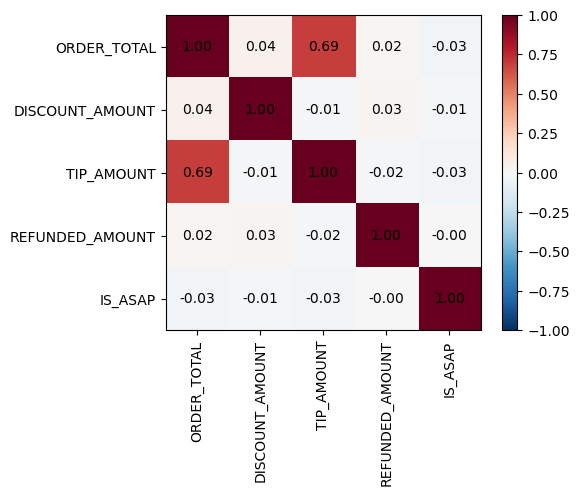

In [33]:
import matplotlib.pyplot as plt

cols = ['ORDER_TOTAL', 'DISCOUNT_AMOUNT', 'TIP_AMOUNT', 'REFUNDED_AMOUNT', 'IS_ASAP']

corr = Doordash[cols].corr()

fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)

ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=90)
ax.set_yticklabels(cols)

for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha='center', va='center')

plt.colorbar(im)
plt.tight_layout()
plt.show()

A correlation of 0.69 is fairly strong (1.0 would mean perfectly in sync, 0 would mean no relationship at all). So while it's not a 1:1 relationship, there's a clear pattern: as order size goes up, tip amount tends to go up too. if tips scale roughly with order size, then tip income for Dashers is naturally higher on bigger orders — which connects back to the catering/group-order opportunity (bigger orders = bigger tips = more attractive deliveries for Dashers) and to the Dasher pay-floor discussion (a flat minimum payout matters most for small orders, since those are the ones most likely to come with small or no tips).

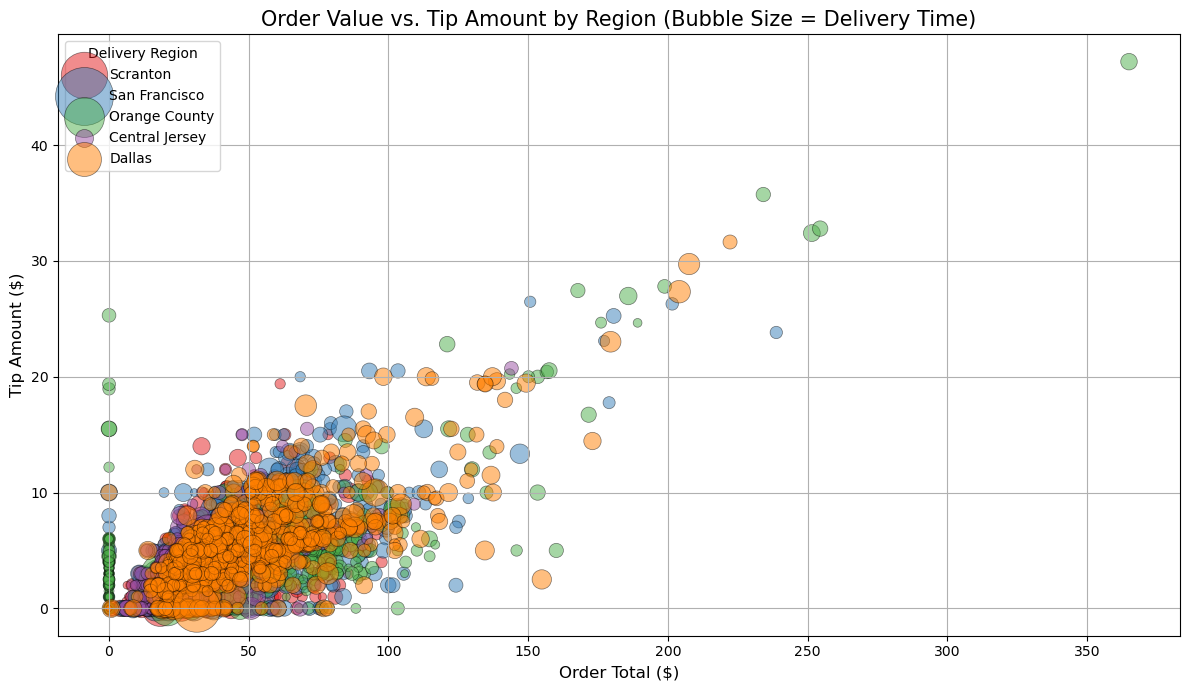

In [34]:
import matplotlib.pyplot as plt

top_regions = Doordash['DELIVERY_REGION'].value_counts().head(5).index.tolist()
plot_df = Doordash[Doordash['DELIVERY_REGION'].isin(top_regions)]

fig, ax = plt.subplots(figsize=(12,7))

colors = plt.cm.Set1(range(len(top_regions)))
for color, region in zip(colors, top_regions):
    sub = plot_df[plot_df['DELIVERY_REGION']==region]
    ax.scatter(
        sub['ORDER_TOTAL'], sub['TIP_AMOUNT'],
        s=sub['total_time_min'].fillna(5)*3,   # bubble size = delivery time
        c=[color], label=region,
        alpha=0.5, edgecolors='black', linewidths=0.5
    )

ax.set_title("Order Value vs. Tip Amount by Region (Bubble Size = Delivery Time)", fontsize=15)
ax.set_xlabel("Order Total ($)", fontsize=12)
ax.set_ylabel("Tip Amount ($)", fontsize=12)
ax.legend(title="Delivery Region")
ax.grid(True)
plt.tight_layout()
plt.show()

Orange County (green) shows up at the highest order totals, confirming it's the region driving those big "catering-style" orders. Dallas (orange) bubbles look noticeably bigger at lower order totals compared to other regions — bigger bubble = longer delivery time, so this is a visual confirmation that Dallas has slower deliveries even on smaller orders, tying back to the cancellation/slowness issue flagged earlier.

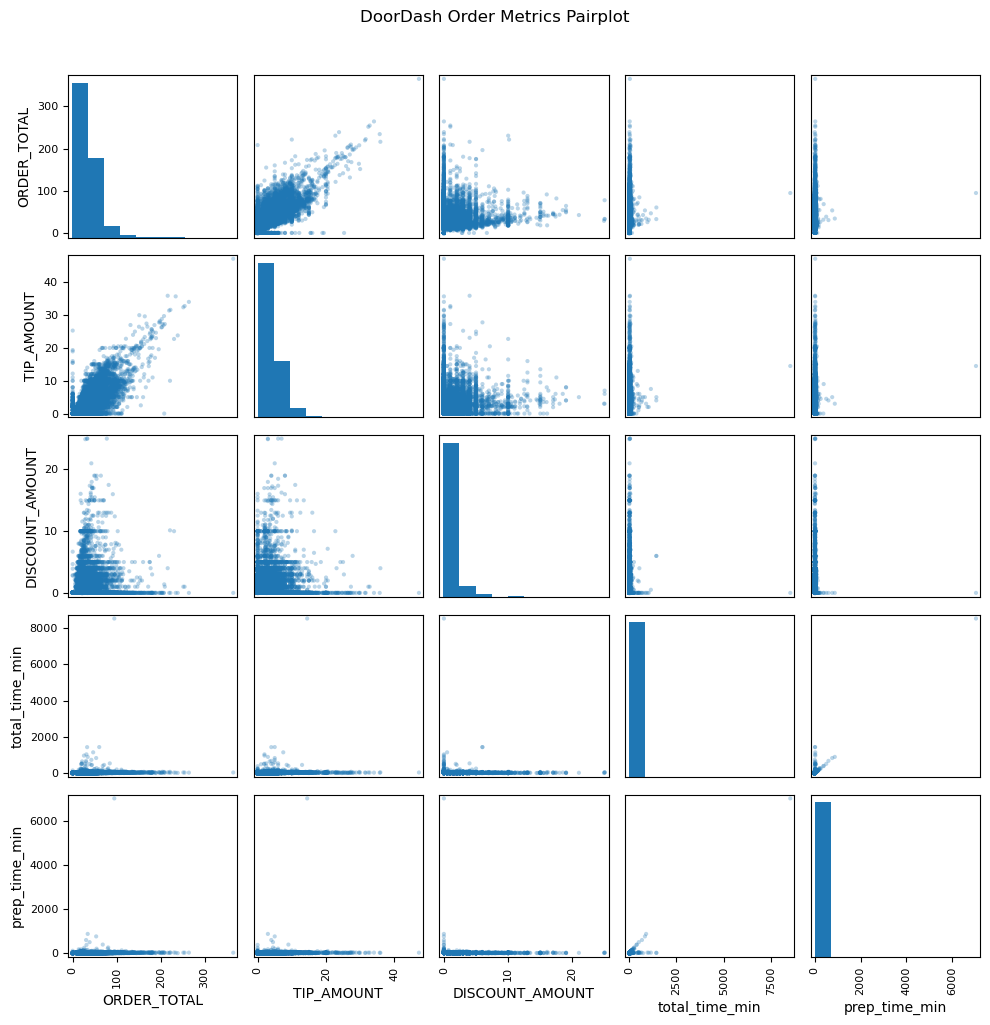

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

cols = ['ORDER_TOTAL', 'TIP_AMOUNT', 'DISCOUNT_AMOUNT', 'total_time_min', 'prep_time_min']

pd.plotting.scatter_matrix(Doordash[cols], figsize=(10,10), diagonal='hist', alpha=0.3)
plt.suptitle("DoorDash Order Metrics Pairplot", y=1.02)
plt.tight_layout()
plt.show()